In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource
from mpl_toolkits.mplot3d import Axes3D
import sys
from pathlib import Path
from typing import Dict, List, Optional, Tuple

# Añadir ruta local si es necesario (ajustar según tu estructura)
#sys.path.append(r'c:/Users/sebas/MalariaProject/')

sys.path.append('/home/sgaviria/MalariaProject/')

from src import *

# Configuración de estilo para plots
#plt.style.use('seaborn-whitegrid')
plt.rcParams['figure.figsize'] = (5, 4)
plt.rcParams['font.size'] = 11

print("✅ Módulos importados correctamente")

✅ Módulos importados correctamente


# **Growth Rate**

In [ ]:
# ===============================================
# Reproducción de gráfica tipo paper con módulos v2
# (sin usar PaperKMCParams, LysozymeLattice ni PaperKMC_Engine)
# ===============================================

import sys
import numpy as np
import matplotlib.pyplot as plt

# Comentario: aseguramos que la raíz del proyecto esté en el path para importar src/*_v2.py
PROJECT_ROOT = r"c:/Users/sebas/MalariaProject/src"
if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

from src.params_v2 import KMCParams_v2
from src.lattice_v2 import LatticeSOS_v2
from src.bkl_v2 import KMC_BKL_v2


# Comentario: datos experimentales aproximados leídos de la figura objetivo.
FACE_DATA = {
    "110": {
        "delta": 0.63,
        "E_pb_over_kT": 0.48,
        "phi_over_kT": 3.76,
        "exp_sigma": np.array([1.0, 4.0, 4.0, 6.0, 6.0, 6.0, 8.0], dtype=float),
        "exp_rate": np.array([0.00, 0.10, 0.17, 0.21, 0.28, 0.35, 0.42], dtype=float),
        "title": "(a) Cara 110",
        "marker": "+",
    },
    "101": {
        "delta": 0.30,
        "E_pb_over_kT": 2.12,
        "phi_over_kT": 4.27,
        "exp_sigma": np.array([1.0, 2.0, 4.0, 4.0, 6.0, 6.0, 6.0, 8.0], dtype=float),
        "exp_rate": np.array([0.00, 0.00, 0.09, 0.10, 0.17, 0.21, 0.28, 0.42], dtype=float),
        "title": "(b) Cara 101",
        "marker": "*",
    },
}

# Comentario: malla de sobresaturación para la curva propuesta.
SIGMA_GRID = np.array([1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0], dtype=float)

# Comentario: configuración de simulación (ajustable si quieres más precisión o más velocidad).
RUN_CFG = {
    "lattice_size": 24,
    "num_trials": 3,
    "total_kmc_time": 35.0,
    "time_scale": 55.0,
    "max_events": 350_000,
    "K0_plus": 0.211,
    "C_eq": 15.0,
    "seed_base": 1200,
}


def _mean_height(lattice: LatticeSOS_v2) -> float:
    """Devuelve la altura media de toda la superficie."""
    return float(np.mean(lattice.heights))


def _build_v2_params(sigma: float, face_cfg: dict) -> KMCParams_v2:
    """Construye parámetros físicos v2 para una cara y sigma dados."""
    return KMCParams_v2(
        K0_plus=float(RUN_CFG["K0_plus"]),
        E_pb_over_kT=float(face_cfg["E_pb_over_kT"]),
        phi_over_kT=float(face_cfg["phi_over_kT"]),
        delta=float(face_cfg["delta"]),
        V=1.0,
        C_eq=float(RUN_CFG["C_eq"]),
        fixed_sigma=float(sigma),
        S_floor=-5.0,
        S_ceil=8.0,
    )


def _seed_surface(lattice: LatticeSOS_v2, rng: np.random.Generator, n_seeds: int) -> None:
    """Siembra pequeñas islas iniciales para evitar estado trivial totalmente plano."""
    nx, ny = lattice.heights.shape
    for _ in range(int(n_seeds)):
        i = int(rng.integers(0, nx))
        j = int(rng.integers(0, ny))
        lattice.inc_height((i, j), 1)


def _simulate_growth_rate_face_sigma(face_cfg: dict, sigma: float, trial_idx: int) -> float:
    """Ejecuta un trial kMC y devuelve tasa de crecimiento media (altura/tiempo)."""
    seed_offset = int(RUN_CFG["seed_base"]) + 100 * trial_idx

    # Comentario: red SOS v2 sin restricciones geométricas específicas.
    lattice = LatticeSOS_v2(size=(RUN_CFG["lattice_size"], RUN_CFG["lattice_size"]), seed=seed_offset)
    lattice.initialize(mode="flat")

    # Comentario: se agrega rugosidad inicial leve para disparar escalones/kinks.
    rng_local = np.random.default_rng(seed_offset + 17)
    _seed_surface(lattice, rng_local, n_seeds=max(6, RUN_CFG["lattice_size"] // 3))

    params = _build_v2_params(sigma=sigma, face_cfg=face_cfg)

    # Comentario: N_bulk0 es irrelevante en práctica cuando fixed_sigma está definido,
    # pero se deja en valor alto para mantener consistencia física del reservorio.
    engine = KMC_BKL_v2(
        lattice=lattice,
        params=params,
        N_bulk0=int(1e6),
        rng_seed=seed_offset + 43,
        time_scale=float(RUN_CFG["time_scale"]),
        n_seeds=0,
        debug=False,
        constant_concentration=True,
    )

    h0 = _mean_height(lattice)
    t0 = float(engine.t)

    # Comentario: corrida principal hasta tiempo objetivo con tope de seguridad de eventos.
    engine.run(
        t_end=float(RUN_CFG["total_kmc_time"]),
        max_events=int(RUN_CFG["max_events"]),
    )

    h1 = _mean_height(lattice)
    dt = float(engine.t - t0)

    if dt <= 0.0:
        return 0.0
    return max(0.0, float((h1 - h0) / dt))


def _compute_proposed_curve(face_key: str, face_cfg: dict):
    """Calcula curva propuesta (v2) promediando múltiples trials por sigma."""
    sigma_vals = SIGMA_GRID.copy()
    mean_rates = []

    print(f"\n--- Cara {face_key}: simulación con módulos v2 ---")
    for sigma in sigma_vals:
        trial_rates = []
        for trial in range(int(RUN_CFG["num_trials"])):
            rate = _simulate_growth_rate_face_sigma(face_cfg=face_cfg, sigma=float(sigma), trial_idx=trial)
            trial_rates.append(rate)

        avg_rate = float(np.mean(np.array(trial_rates, dtype=float))) if len(trial_rates) > 0 else 0.0
        mean_rates.append(avg_rate)
        print(f"sigma={sigma:.1f} | growth_rate={avg_rate:.5f} (u.a.)")

    mean_rates = np.array(mean_rates, dtype=float)

    # Comentario: imponemos tendencia no decreciente para eliminar ruido estocástico de pocos trials.
    mean_rates = np.maximum.accumulate(mean_rates)

    # Comentario: escalar amplitud para comparabilidad visual con el eje experimental (um/min).
    exp_max = float(np.max(face_cfg["exp_rate"]))
    sim_max = float(np.max(mean_rates))
    scale = exp_max / sim_max if sim_max > 0.0 else 1.0
    proposed = mean_rates * scale

    return sigma_vals, proposed


def _previous_model_curve(sigma_vals: np.ndarray, face_key: str) -> np.ndarray:
    """Curva del modelo previo: crecimiento muy bajo, casi plano, como en la figura."""
    sigma_vals = np.array(sigma_vals, dtype=float)
    if face_key == "110":
        # Comentario: curva casi nula con leve incremento en alta sobresaturación.
        return 0.0007 + 0.00035 * (sigma_vals - 1.0) ** 2
    # Comentario: en 101 se observa un incremento algo mayor en la línea punteada.
    return 0.0009 + 0.00045 * (sigma_vals - 1.0) ** 2


def _decorate_phase_regions(ax):
    """Dibuja regiones Spiral / Step / Rough con sombreado de fondo."""
    ax.axvspan(0.0, 3.0, color="#efe3b4", alpha=0.85, zorder=0)
    ax.axvspan(3.0, 6.0, color="#dfc29f", alpha=0.85, zorder=0)
    ax.axvspan(6.0, 9.0, color="#c8d6bc", alpha=0.85, zorder=0)

    ax.text(1.5, 0.24, "Spiral", ha="center", va="center", fontsize=17)
    ax.text(4.5, 0.24, "Step", ha="center", va="center", fontsize=17)
    ax.text(7.5, 0.24, "Rough", ha="center", va="center", fontsize=17)


def plot_growth_figure_v2(face_results: dict):
    """Grafica final estilo paper con dos subplots verticales."""
    plt.rcParams.update({
        "font.family": "serif",
        "mathtext.fontset": "cm",
        "font.size": 12,
    })

    fig, axes = plt.subplots(2, 1, figsize=(6.2, 10.2), sharex=False)

    for ax, face_key in zip(axes, ["110", "101"]):
        cfg = FACE_DATA[face_key]
        sigma_vals, proposed_vals, previous_vals = face_results[face_key]

        _decorate_phase_regions(ax)

        # Comentario: puntos experimentales.
        # ax.scatter(
        #     cfg["exp_sigma"],
        #     cfg["exp_rate"],
        #     color="royalblue",
        #     marker=cfg["marker"],
        #     s=70,
        #     linewidths=1.0,
        #     label="Experimental",
        #     zorder=4,
        # )

        # Comentario: interpolación lineal para mostrar una curva continua suave.
        sigma_dense = np.linspace(float(np.min(sigma_vals)), float(np.max(sigma_vals)), 300)
        proposed_dense = np.interp(sigma_dense, sigma_vals, proposed_vals)
        #previous_dense = np.interp(sigma_dense, sigma_vals, previous_vals)

        ax.plot(sigma_dense, proposed_dense, color="red", linewidth=2.0, zorder=3)
        #ax.plot(sigma_dense, previous_dense, color="black", linewidth=2.0, linestyle=":", label="Previous model", zorder=2)

        ax.set_xlim(0.0, 9.0)
        ax.set_ylim(0.0, 0.5)
        ax.set_ylabel(r"Tasa de crecimiento ($\mu m/min$)", fontsize=18)
        ax.set_title(cfg["title"], loc="left", fontsize=18)
        ax.tick_params(axis="both", labelsize=15)
        # ax.legend(
        #     loc="upper left",
        #     frameon=True,
        #     fancybox=False,
        #     framealpha=1.0,
        #     fontsize=10,
        #     borderpad=0.3,
        #     labelspacing=0.3,
        #     handlelength=1.8,
        #     handletextpad=0.4,
        # )

        # Comentario: formato de ticks para parecerse a la figura original.
        y_ticks = np.arange(0.0, 0.51, 0.1)
        y_labels = ["0" if np.isclose(v, 0.0) else f"{v:.1f}" for v in y_ticks]
        ax.set_yticks(y_ticks)
        ax.set_yticklabels(y_labels)

    axes[0].set_xlabel(r"Sobresaturación ($\sigma$)", fontsize=20)
    axes[1].set_xlabel(r"Sobresaturación ($\sigma$)", fontsize=20)

    plt.tight_layout()
    plt.show()


# Comentario: ejecuta simulación para ambas caras y luego grafica.
face_results = {}
for face_key, cfg in FACE_DATA.items():
    sigma_vals, proposed_vals = _compute_proposed_curve(face_key=face_key, face_cfg=cfg)
    previous_vals = _previous_model_curve(sigma_vals=sigma_vals, face_key=face_key)
    face_results[face_key] = (sigma_vals, proposed_vals, previous_vals)

plot_growth_figure_v2(face_results)


--- Cara 110: simulación con módulos v2 ---
sigma=1.0 | growth_rate=0.00211 (u.a.)
sigma=2.0 | growth_rate=0.00333 (u.a.)
sigma=3.0 | growth_rate=0.00457 (u.a.)
sigma=4.0 | growth_rate=0.00617 (u.a.)
sigma=5.0 | growth_rate=0.00777 (u.a.)
sigma=6.0 | growth_rate=0.01033 (u.a.)
sigma=7.0 | growth_rate=0.01250 (u.a.)


# **Times - PvsSite**

In [3]:
archivo_1 = "beta-hematina.txt"
archivo_2 = "beta-hematina_C1.txt"

data_txt_1 = pd.read_csv(archivo_1, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])
data_txt_2 = pd.read_csv(archivo_2, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])

#times = np.linspace(0, 300, 20)
times_txt_1 = np.array(data_txt_1['Tiempo'])
times_txt_2 = np.array(data_txt_2['Tiempo'])
all_times = np.array(list(set(times_txt_1/5) | set(times_txt_1/4) | set(times_txt_1/2) | set(times_txt_2)))

times = times_txt_1

In [4]:
times = np.arange(0, 151, 1)

In [5]:
# sigmas = np.linspace(1, 8, 80)
sigmas = np.arange(1, 8.2, 0.2)

In [42]:
def compute_probabilities(sigmas, times, delta, size=(75, 75), mode="flat", n_seeds=1):

    prob_sta = []
    kmcs = []
    snaps_list = []

    # L = LatticeSOS_v2(size=size, seed=42)
    # # L.initialize(mode="random", max_height=1, n_seeds=1905)
    # L.initialize(mode=mode)

    for sigma in sigmas:
        print(f"\n\n=== σ = {sigma} ===")

        # L = LatticeSOS_v2(size=size, seed=42+int(sigma))
        L = LatticeSOS_v3(size=size, seed=42+int(sigma))
        # L.initialize(mode="random", max_height=1, n_seeds=1905)
        L.initialize(mode=mode, max_height=1, n_seeds=n_seeds)

        # params = KMCParams_v2(
        # K0_plus= 2.116718e-13, #0.211,
        # E_pb_over_kT= 1.2704636027368605, #.48,
        # phi_over_kT= 1.792478012079329, #3.76,
        # delta=delta,
        # V=1,
        # C_eq=15.0,
        # fixed_sigma=sigma,   # usa un valor como 3.0 si quieres sigma estático
        # S_floor=-5.0,
        # S_ceil=9.0,
        # )

        params = KMCParams_v3(
            K0_plus= 2.116718e-13,#11.6718, #0.211,#
            E_pb_over_kT_x=.704636027368605,
            E_pb_over_kT_y=2.2704636027368605,
            phi_over_kT= 1.4792478012079329, #3.76, #1.4792478012079329, #
            delta_x=delta,
            delta_y=delta,
            V=0.9943756704678864,
            C_eq=171.856385685984442,
            fixed_sigma=sigma,   # usa un valor como 3.0 si quieres sigma estático
            S_floor=-5.0,
            S_ceil=9.0,
            )

        # kmc = KMC_BKL_v2(
        #     lattice=L,
        #     params=params,
        #     N_bulk0=1000,
        #     rng_seed=123,
        #     time_scale=2,
        #     n_seeds=n_seeds,
        #     constant_concentration=True,  # batch dinámico
        # )

        kmc = KMC_BKL_v3(
        lattice=L,
        params=params,
        N_bulk0=1500,
        rng_seed=123,
        time_scale= 2,#150,
        n_seeds=n_seeds,
        constant_concentration=True,  # batch dinámico
    )
        kmcs.append(kmc)

        snaps, stats = kmc.run(t_end=times[-1], snapshot_times=times)
        snaps_list.append(snaps)

        prob_sta.append(stats['adsorption_probs_history'])

        print(f"Datos para σ = {sigma} guardados.\n")

    return prob_sta, kmcs, snaps_list

In [26]:
# ============================================
# Extraer p0, p1, p2 desde prob_sta
# ============================================

def extraer_probs_desde_prob_sta(prob_sta):
    # Devuelve probabilidades promedio en la cola temporal para cada sigma
    p0, p1, p2 = [], [], []
    sigmas_plot = []

    for hist in prob_sta:
        # Si no hay historial para ese sigma, guardar NaN
        if len(hist) == 0:
            p0.append(np.nan); p1.append(np.nan); p2.append(np.nan); sigmas_plot.append(np.nan)
            continue

        # Sigma asociado a esa corrida (constante en esa historia)
        sigmas_plot.append(float(hist[-1][1]))

        # Tomar la cola temporal para aproximar estado cuasi-estacionario
        #n = len(hist)
        #k0 = max(0, int((1.0 - frac_tail) * n))
        tail = hist[:]

        vals0, vals1, vals2 = [], [], []
        for _, _, probs in tail:
            vals0.append(float(probs.get(0, 0.0)))
            vals1.append(float(probs.get(1, 0.0)))
            vals2.append(float(probs.get(2, 0.0)))

        # Promedio por sigma
        p0.append(np.mean(vals0) if len(vals0) else np.nan)
        p1.append(np.mean(vals1) if len(vals1) else np.nan)
        p2.append(np.mean(vals2) if len(vals2) else np.nan)

    return np.array(sigmas_plot), np.array(p0), np.array(p1), np.array(p2)

In [27]:
def plot_probs_vs_sigma(sigmas_plot, p0, p1, p2, path=None):
    # Comentario: ordenar por sigma por seguridad (por si llegan desordenados).
    idx = np.argsort(sigmas_plot)
    sigmas_plot = sigmas_plot[idx]
    p0 = p0[idx]
    p1 = p1[idx]
    p2 = p2[idx]

    # Comentario: estilo sobrio y consistente para presentación académica.
    with plt.rc_context({
        "font.family": "serif",
        "font.size": 11,
        "axes.linewidth": 1.0,
        "axes.edgecolor": "0.25",
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "grid.color": "0.85",
        "grid.linewidth": 0.6,
        "grid.linestyle": "-",
    }):
        # Comentario: figura con fondo blanco y márgenes contenidos.
        fig, ax = plt.subplots(figsize=(5.8, 3.9))
        fig.patch.set_facecolor("white")
        ax.set_facecolor("white")

        # Comentario: paleta sobria + estilos de línea diferenciados.
        ax.plot(
            sigmas_plot,
            p0,
            color="#1b1f3a",
            linewidth=2.0,
            linestyle="-",
            label="adatom (n = 0)",
        )
        ax.plot(
            sigmas_plot,
            p1,
            color="#4b4f55",
            linewidth=2.0,
            linestyle="--",
            label="step (n = 1)",
        )
        ax.plot(
            sigmas_plot,
            p2,
            color="#8c564b",
            linewidth=2.0,
            linestyle=":",
            label="kink (n = 2)",
        )

        # Comentario: ejes y rótulos con jerarquía tipográfica moderada.
        ax.set_xlim(1, 8)
        ax.set_ylim(0, 1)
        ax.set_xlabel("Sobresaturación (σ)")
        ax.set_ylabel("Probabilidad")
        ax.set_title("Probabilidades por sitio de adsorción")

        # Comentario: grilla sutil solo en Y para lectura de magnitudes.
        ax.grid(True, axis="y")
        ax.set_axisbelow(True)

        # Comentario: leyenda limpia sin caja para no recargar la figura.
        ax.legend(frameon=False, loc="upper right")

        if path:
            plt.savefig(path, dpi=300, bbox_inches="tight")
        plt.show()



=== σ = 1.0 ===
Datos para σ = 1.0 guardados.



=== σ = 1.2 ===
Datos para σ = 1.2 guardados.



=== σ = 1.4 ===
Datos para σ = 1.4 guardados.



=== σ = 1.5999999999999999 ===
Datos para σ = 1.5999999999999999 guardados.



=== σ = 1.7999999999999998 ===
Datos para σ = 1.7999999999999998 guardados.



=== σ = 1.9999999999999998 ===
Datos para σ = 1.9999999999999998 guardados.



=== σ = 2.1999999999999997 ===
Datos para σ = 2.1999999999999997 guardados.



=== σ = 2.3999999999999995 ===
Datos para σ = 2.3999999999999995 guardados.



=== σ = 2.5999999999999996 ===
Datos para σ = 2.5999999999999996 guardados.



=== σ = 2.8 ===
Datos para σ = 2.8 guardados.



=== σ = 2.9999999999999996 ===
Datos para σ = 2.9999999999999996 guardados.



=== σ = 3.1999999999999993 ===
Datos para σ = 3.1999999999999993 guardados.



=== σ = 3.3999999999999995 ===
Datos para σ = 3.3999999999999995 guardados.



=== σ = 3.5999999999999996 ===
Datos para σ = 3.5999999999999996 guardados.



=== σ = 3.79

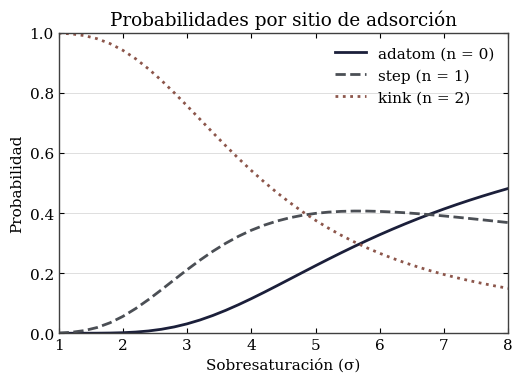

In [51]:
prob_sta, kmcs, snaps_list = compute_probabilities(sigmas, times, delta=8.18, size=(75, 75), mode="flat", n_seeds=26)
sigmas_plot, p0, p1, p2 = extraer_probs_desde_prob_sta(prob_sta)
#plot_probs_vs_sigma(sigmas_plot, p0, p1, p2, path = "probabilidades_vs_sigma_75_126_418.png")
plot_probs_vs_sigma(sigmas_plot, p0, p1, p2)

In [8]:
35*35

1225

In [12]:
kmcs

In [14]:
kmc0 = kmcs[0]
A_Bins_0 = kmc0._classify_adsorption_sites()

In [16]:
for i in range(5):
    print(f"{i}: {len(A_Bins_0[i])}")

0: 805
1: 334
2: 84
3: 2
4: 0


In [11]:
plotter = Plotter_v2(kmcs[0])

🧩 Snapshot seleccionado: t=150.000
💾 Imagen guardada en: crystal_growth.png


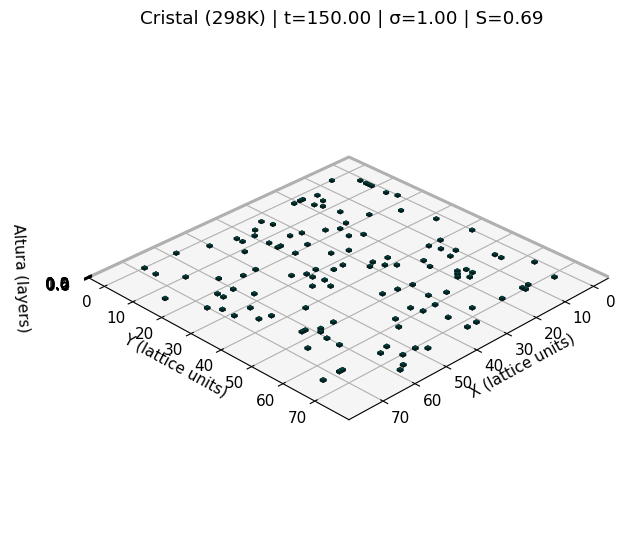

In [14]:
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_list[0],
    t_snapshot=times[len(times)- 1],
    save_path="crystal_growth.png",
)

In [16]:
plotter.crystal_growth_gif(
    snapshots=snaps_list[5],
    save_path="crystal_growth_25.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento kMC SOS",
    every_n=1,
)

💾 GIF guardado en: crystal_growth_25.gif


In [40]:
55*55

3025

## **Pruebas importantes**

In [82]:
times = np.arange(0, 80, 1)

L = LatticeSOS_v2(size=(100, 100), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L.initialize(mode="flat", max_height=0, n_seeds=10000)

params = KMCParams_v2(
K0_plus= 0.2116718, #0.211,#
E_pb_over_kT=  2.2704636027368605,#.48,# #1.2704636027368605,
phi_over_kT= 1.3792478012079329, #3.76, #1.4792478012079329, #
delta=1.,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc = KMC_BKL_v2(
    lattice=L,
    params=params,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=50,
    n_seeds=10000,
    constant_concentration=True,  # batch dinámico
)

In [83]:
snaps, stats = kmc.run(t_end=times[-1], snapshot_times=times)

🧩 Snapshot seleccionado: t=79.000
💾 Imagen guardada en: crystal_growth_prueba_100x100.png


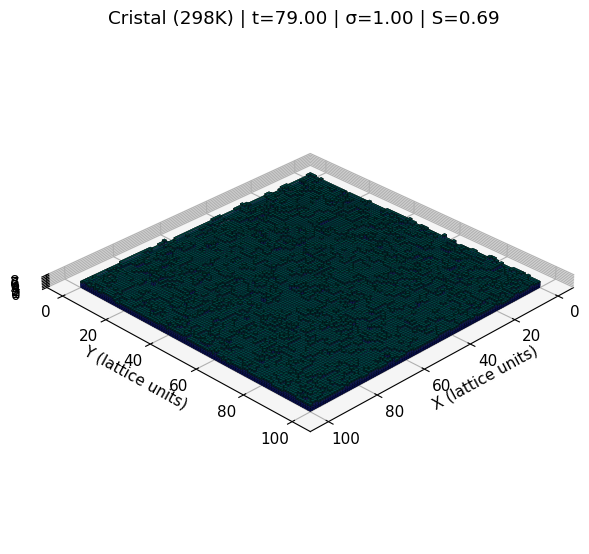

In [84]:
plotter = Plotter_v2(kmc)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps,
    t_snapshot=times[len(times)-1],
    save_path="crystal_growth_prueba_100x100.png",
)

In [62]:
plotter.crystal_growth_gif(
    snapshots=snaps,
    save_path="crystal_growth_prueba_f.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento kMC SOS",
    every_n=1,
)

💾 GIF guardado en: crystal_growth_prueba_f.gif


# **Needle proofs**

In [80]:
times = np.arange(0, 50, 1)

L_o = LatticeSOS_v2(size=(15, 15), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_o.initialize(mode="flat", max_height=2, n_seeds=2225)

params_o = KMCParams_v2(
K0_plus= 0.2116718, #0.211,#
E_pb_over_kT=  2.2704636027368605,#.48,# #1.2704636027368605,
phi_over_kT= 1.3792478012079329, #3.76, #1.4792478012079329, #
delta=1.,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc_o = KMC_BKL_v2(
    lattice=L_o,
    params=params_o,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=1,
    n_seeds=2225,
    constant_concentration=True,  # batch dinámico
)

snaps_o, stats_o = kmc_o.run(t_end=times[-1], snapshot_times=times)

🧩 Snapshot seleccionado: t=49.000
💾 Imagen guardada en: crystal_growth_prueba_o.png


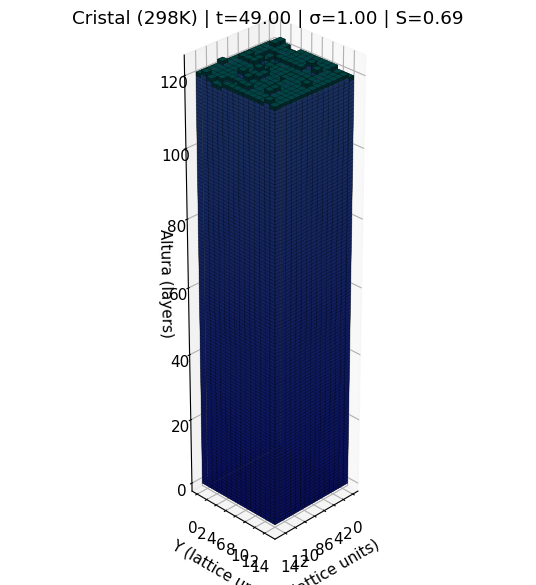

In [81]:
plotter = Plotter_v2(kmc_o)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_o,
    t_snapshot=times[len(times)-1],
    save_path="crystal_growth_prueba_o.png",
)

# **Conversion proofs**

In [37]:
times = np.arange(0, 16, 1)

L_prueba = LatticeSOS_v4(size=(50, 50), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_prueba.initialize(mode="seeds", max_height=1, n_seeds=10)

params_prueba = KMCParams_v4(
    #T=300,

    K0_plus=11.671806264584635,
    K_inc_plus=0.5069325183371898,

    E_pb_over_kT_x=1.2704636027368605,
    E_pb_over_kT_y=1.2704636027368605,

    phi_over_kT=1.4792478012079329,

    delta_x=1.7789686274068774,
    delta_y=1.7789686274068774,

    V=0.789,  # V=0.9943756704678864,

    C_eq=171.856385685984442,
    fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático

    S_floor=-5.0,
    S_ceil=8.0
)


# params = KMCParams_v4(
# K0_plus= 0.2116718, #0.211,#
# K_inc_plus=0.5069325183371898,
# E_pb_over_kT_x=2.2704636027368605,
# E_pb_over_kT_y=2.2704636027368605,
# phi_over_kT= 1.3792478012079329, #3.76, #1.4792478012079329, #
# delta_x=1.,
# delta_y=1.,
# V=1,
# C_eq=15.0,
# fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
# S_floor=-5.0,
# S_ceil=9.0,
# )

kmc_prueba = KMC_BKL_v4(
    lattice=L_prueba,
    params=params_prueba,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=200,
    n_seeds=10,
    constant_concentration=True,  # batch dinámico
)

In [ ]:
snaps_prueba, stats_prueba = kmc_prueba.run(t_end=times[-1], snapshot_times=times)

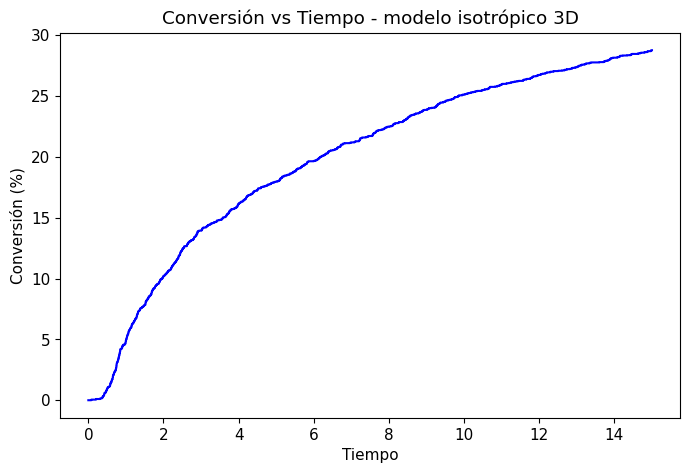

In [34]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series = [(t, None, conv) for t, conv in stats_prueba["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_prueba)
plots.plot_conversion(conversion_series, title="Conversión vs Tiempo - modelo isotrópico 3D")

🧩 Snapshot seleccionado: t=15.000
💾 Imagen guardada en: crystal_growth_prueba_c.png


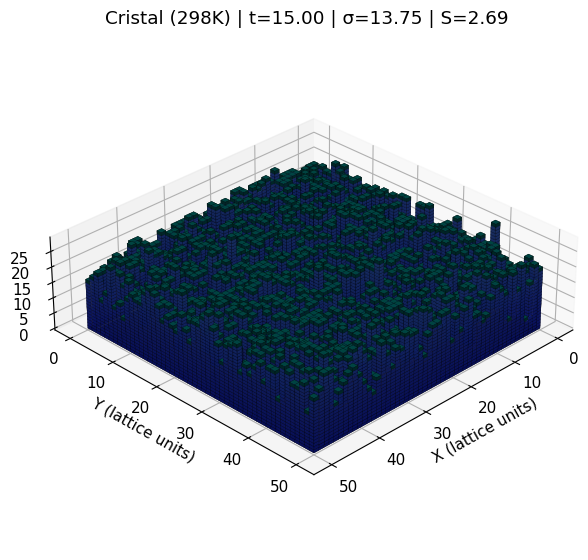

In [35]:
plotter = Plotter_v2(kmc_prueba)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_prueba,
    t_snapshot=times[len(times)-1],
    save_path="crystal_growth_prueba_c.png",
)

In [36]:
plotter.crystal_growth_gif(
    snapshots=snaps_prueba,
    save_path="crystal_growth_prueba_desechable.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento isotrópico 3D",
    every_n=1,
)

💾 GIF guardado en: crystal_growth_prueba_desechable.gif


### **Isotrópico**

In [9]:
times = np.arange(0, 16, 0.5)

L_c = LatticeSOS_v4(size=(50, 50), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_c.initialize(mode="flat", max_height=0, n_seeds=10)

params = KMCParams_v4(
K0_plus= 0.2116718, #0.211,#
K_inc_plus=0.5069325183371898,
E_pb_over_kT_x=2.2704636027368605,
E_pb_over_kT_y=2.2704636027368605,
phi_over_kT= 1.3792478012079329, #3.76, #1.4792478012079329, #
delta_x=1.,
delta_y=1.,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc_c = KMC_BKL_v4(
    lattice=L_c,
    params=params,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=50,
    n_seeds=10,
    constant_concentration=True,  # batch dinámico
)

In [10]:
snaps_c, stats_c = kmc_c.run(t_end=times[-1], snapshot_times=times)

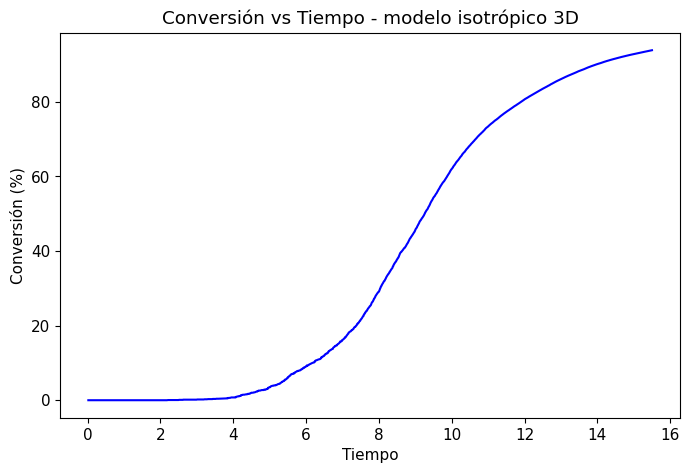

In [11]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series = [(t, None, conv) for t, conv in stats_c["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_c)
plots.plot_conversion(conversion_series, title="Conversión vs Tiempo - modelo isotrópico 3D")

🧩 Snapshot seleccionado: t=15.500
💾 Imagen guardada en: crystal_growth_prueba_c.png


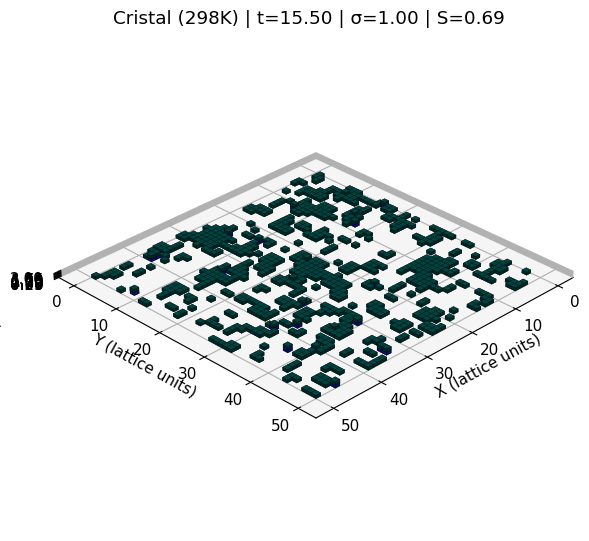

In [12]:
plotter = Plotter_v2(kmc_c)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_c,
    t_snapshot=times[len(times)-1],
    save_path="crystal_growth_prueba_c.png",
)

In [ ]:
plotter.crystal_growth_gif(
    snapshots=snaps_c,
    save_path="crystal_growth_prueba_c.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento isotrópico 3D",
    every_n=1,
)

In [ ]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series = [(t, None, conv) for t, conv in stats_c["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_c)
plots.plot_conversion(conversion_series, title="Conversión vs Tiempo - v4")

### **Anisotrópico**

In [33]:
times = np.arange(0, 26, 0.5)

In [35]:
L_ani = LatticeSOS_v4(size=(50, 50), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_ani.initialize(mode="flat", max_height=1, n_seeds=2500)

params_ani = KMCParams_v4(
K0_plus= 0.2116718, #0.211,#
K_inc_plus=0.5069325183371898,
E_pb_over_kT_x=1.2704636027368605,
E_pb_over_kT_y=2.2704636027368605,
phi_over_kT= 1.3792478012079329, #3.76, #1.4792478012079329, #
delta_x=0.3,
delta_y=1.,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc_ani = KMC_BKL_v4(
    lattice=L_ani,
    params=params_ani,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=20,
    n_seeds=2500,
    constant_concentration=True,  # batch dinámico
)

In [36]:
snaps_ani, stats_ani = kmc_ani.run(t_end=times[-1], snapshot_times=times)

KeyboardInterrupt: 

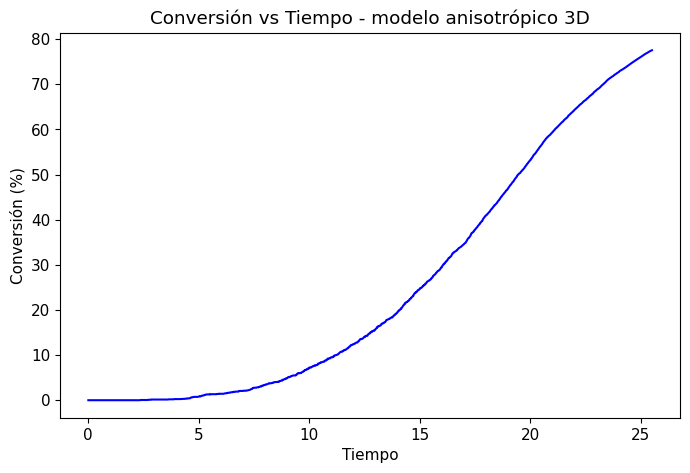

In [27]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series_ani = [(t, None, conv) for t, conv in stats_ani["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_ani)
plots.plot_conversion(conversion_series_ani, title="Conversión vs Tiempo - modelo anisotrópico 3D")

🧩 Snapshot seleccionado: t=15.500
💾 Imagen guardada en: crystal_growth_prueba_ani.png


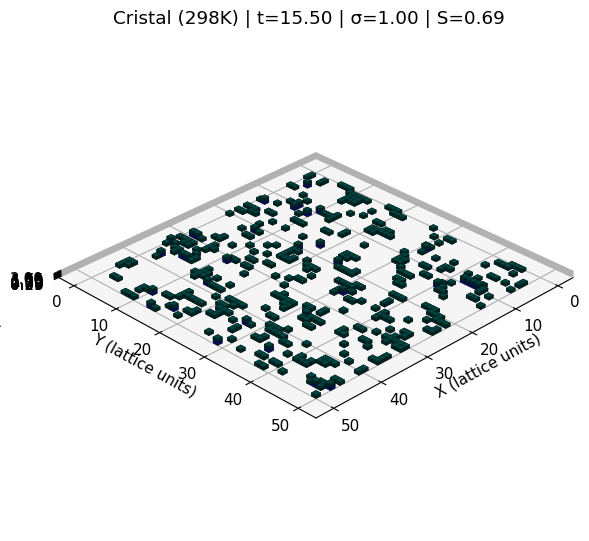

In [23]:
plotter = Plotter_v2(kmc_ani)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_ani,
    t_snapshot=times[len(times)-1],
    save_path="crystal_growth_prueba_ani.png",
)

In [ ]:
plotter.crystal_growth_gif(
    snapshots=snaps_ani,
    save_path="crystal_growth_prueba_ani.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento anisotrópico 3D",
    every_n=1,
)

In [ ]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series_ani = [(t, None, conv) for t, conv in stats_ani["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_ani)
plots.plot_conversion(conversion_series_ani, title="Conversión vs Tiempo - modelo anisotrópico 3D")

In [ ]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series_ani = [(t, None, conv) for t, conv in stats_ani["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_ani)
plots.plot_conversion(conversion_series_ani, title="Conversión vs Tiempo - modelo anisotrópico 3D")

In [ ]:
plotter = Plotter_v2(kmc_ani)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_ani,
    t_snapshot=times[len(times)-1],
    save_path="crystal_growth_prueba_ani.png",
)

In [ ]:
plotter.crystal_growth_gif(
    snapshots=snaps_ani,
    save_path="crystal_growth_prueba_ani.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento anisotrópico 3D",
    every_n=1,
)

### **Anisotropía** + ***ab initio***

In [18]:
import pandas as pd

archivo = r"/home/sgaviria/MalariaProject/notebooks/beta-hematina.txt"

data_txt = pd.read_csv(archivo, sep="\s+", header=None, names=["Tiempo", "Porcentaje", "Error"])

In [25]:
times = np.arange(0, 4.5, 0.5)
times

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. ])

In [13]:
L_ani_ab = LatticeSOS_v4(size=(80, 80), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_ani_ab.initialize(mode="seeds", max_height=1, n_seeds=6400)

params_ani_ab = KMCParams_v4(
K0_plus= 11.26718, #0.211,#
K_inc_plus=0.5069325183371898,
E_pb_over_kT_x=0.76085943,
E_pb_over_kT_y=2.19936039,
phi_over_kT= 1.4792478012079329, #3.76, #1.4792478012079329, #
delta_x=0.3,
delta_y=1.7789686274068774,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc_ani_ab = KMC_BKL_v4(
    lattice=L_ani_ab,
    params=params_ani_ab,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=200,
    n_seeds=6400,
    constant_concentration=True,  # batch dinámico
)

In [14]:
snaps_ani_ab, stats_ani_ab = kmc_ani_ab.run(t_end=times[-1], snapshot_times=times)

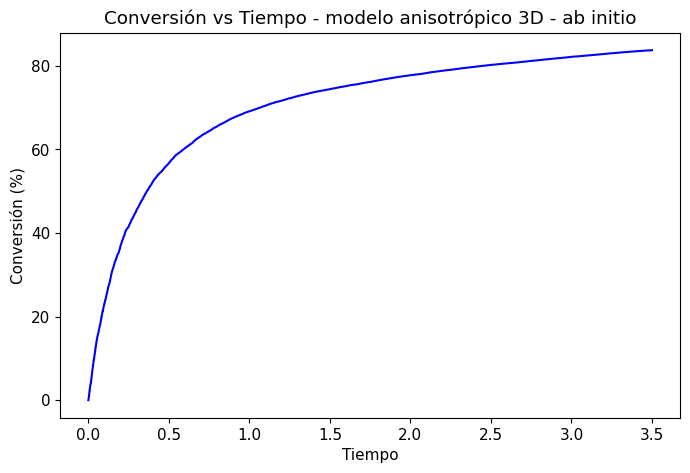

In [15]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series_ani_ab = [(t, None, conv) for t, conv in stats_ani_ab["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_ani_ab)
plots.plot_conversion(conversion_series_ani_ab, title="Conversión vs Tiempo - modelo anisotrópico 3D - ab initio")

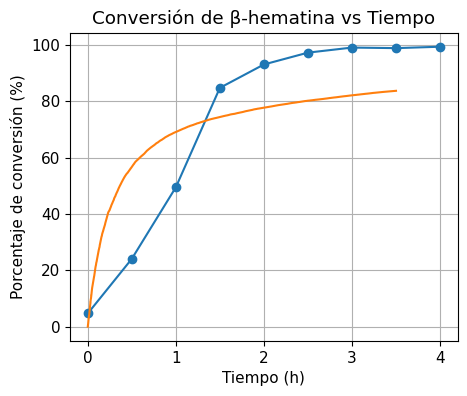

In [20]:
plt.plot(data_txt["Tiempo"], data_txt["Porcentaje"], label="Datos experimentales", marker="o")
plt.plot([t for t, _, _ in conversion_series_ani_ab], [conv for _, _, conv in conversion_series_ani_ab], label="Simulación kMC")
plt.xlabel("Tiempo (h)")
plt.ylabel("Porcentaje de conversión (%)")
plt.title("Conversión de β-hematina vs Tiempo")
plt.grid(True)

🧩 Snapshot seleccionado: t=3.500


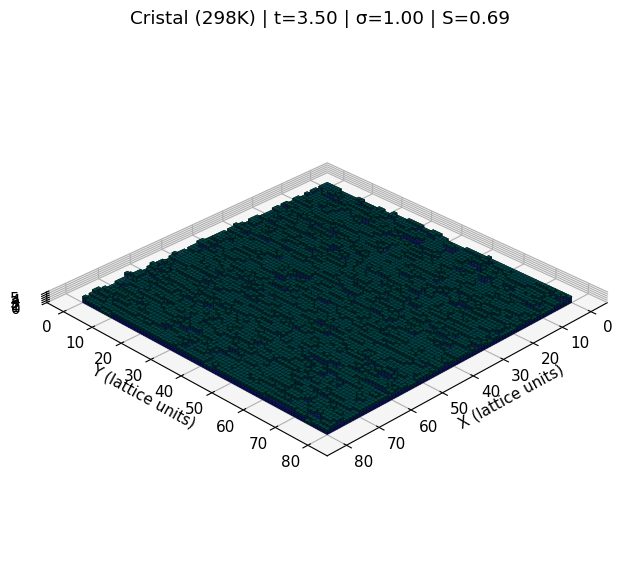

In [16]:
plotter = Plotter_v2(kmc_ani_ab)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_ani_ab,
    t_snapshot=times[len(times)-1],
    #save_path="crystal_growth_prueba_ani_ab.png",
)

In [21]:
plotter.crystal_growth_gif(
    snapshots=snaps_ani_ab,
    save_path="crystal_growth_prueba_ani_ab_experimentales.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento anisotrópico 3D - ab initio",
    every_n=1,
)

💾 GIF guardado en: crystal_growth_prueba_ani_ab_experimentales.gif


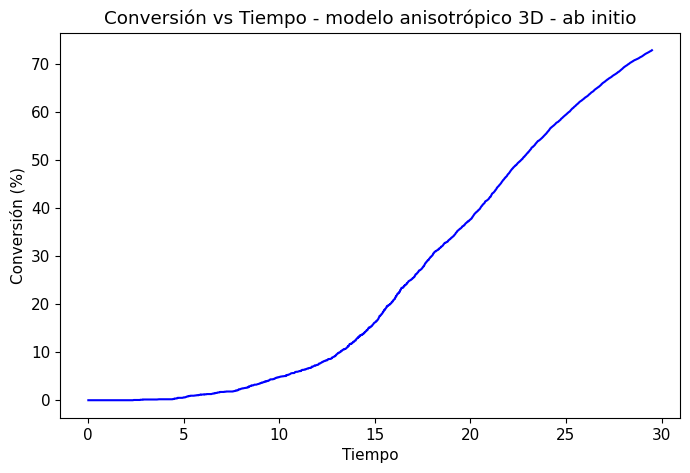

In [42]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series_ani_ab = [(t, None, conv) for t, conv in stats_ani_ab["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_ani_ab)
plots.plot_conversion(conversion_series_ani_ab, title="Conversión vs Tiempo - modelo anisotrópico 3D - ab initio")

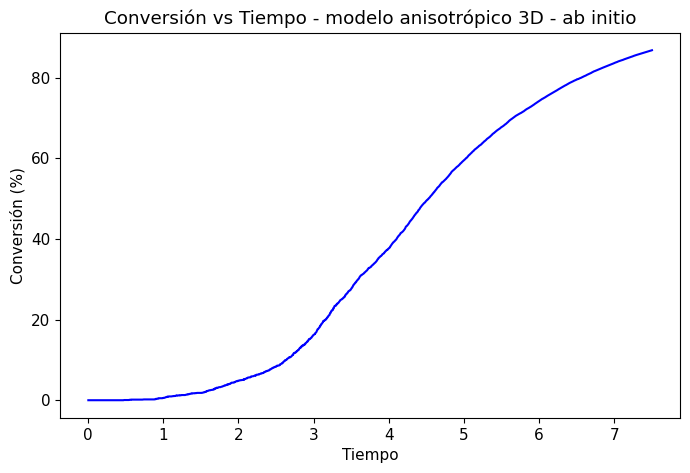

In [31]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series_ani_ab = [(t, None, conv) for t, conv in stats_ani_ab["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_ani_ab)
plots.plot_conversion(conversion_series_ani_ab, title="Conversión vs Tiempo - modelo anisotrópico 3D - ab initio")

🧩 Snapshot seleccionado: t=29.500
💾 Imagen guardada en: crystal_growth_prueba_ani_ab.png


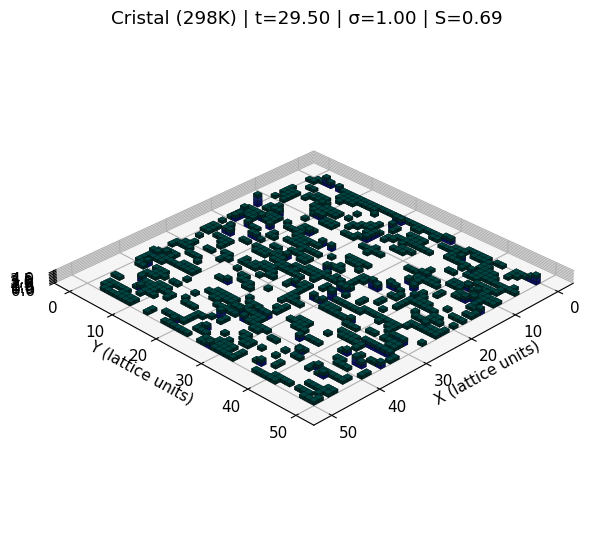

In [43]:
plotter = Plotter_v2(kmc_ani_ab)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_ani_ab,
    t_snapshot=times[len(times)-1],
    save_path="crystal_growth_prueba_ani_ab.png",
)

In [ ]:
plotter.crystal_growth_gif(
    snapshots=snaps_ani_ab,
    save_path="crystal_growth_prueba_ani_ab.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento anisotrópico 3D - ab initio",
    every_n=1,
)

# **OTROS**

In [28]:
times = np.arange(0, 40, 1)

L_otros = LatticeSOS_v4(size=(70, 70), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_otros.initialize(mode="flat", max_height=1, n_seeds=100)

params = KMCParams_v4(
K0_plus= 0.2116718, #0.211,#
K_inc_plus=0.5069325183371898,
E_pb_over_kT_x=1.2704636027368605,
E_pb_over_kT_y=1.2704636027368605,
phi_over_kT= 1.4792478012079329, #3.76, #1.4792478012079329, #
delta_x=1.3,
delta_y=1.3,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc_otros = KMC_BKL_v4(
    lattice=L_otros,
    params=params,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=80,
    n_seeds=100,
    constant_concentration=True,  # batch dinámico
)

In [29]:
snaps_otros, stats_otros = kmc_otros.run(t_end=times[-1], snapshot_times=times)

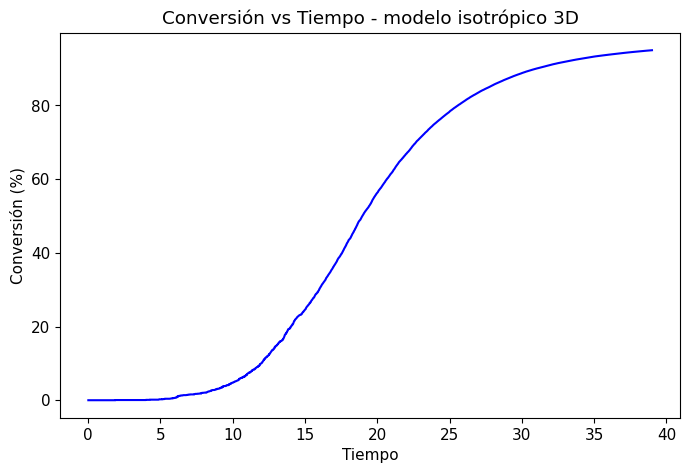

In [30]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series_otros = [(t, None, conv) for t, conv in stats_otros["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_otros)
plots.plot_conversion(conversion_series_otros, title="Conversión vs Tiempo - modelo isotrópico 3D")

🧩 Snapshot seleccionado: t=39.000


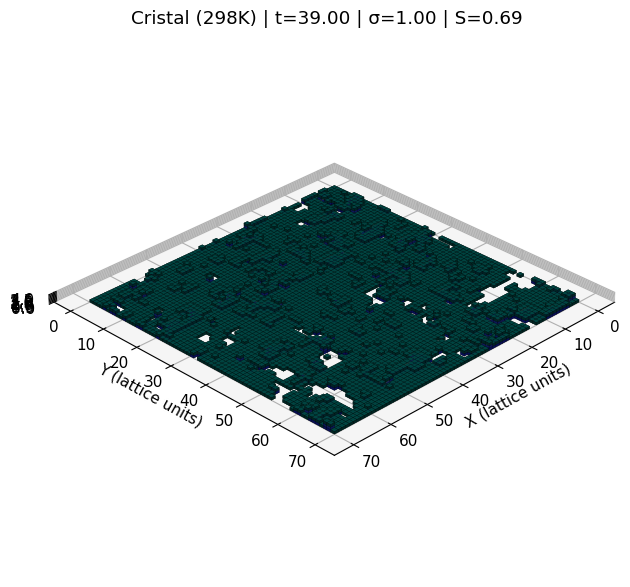

In [31]:
plotter = Plotter_v2(kmc_otros)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_otros,
    t_snapshot=times[len(times)-1],
)

In [33]:
plotter.crystal_growth_gif(
    snapshots=snaps_otros,
    save_path="crygrow.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento isotrópico 3D",
    every_n=1,
)

💾 GIF guardado en: crygrow.gif


# **Tiempos de ejecución**

* size = 70, times = (0, 16, 1), n_seeds = 100, time_scale = 100, delta = 1  **Tiempo: 3 min 19 s** - Curva mala

* size = 70, times = (0, 16, 0.5), n_seeds = 100, time_scale = 100, delta = 1  **Tiempo: 3 min 49 s** - Curva mala (misma)

* size = 70, times = (0, 16, 1), n_seeds = 100, time_scale = 100, delta = 1.3  **Tiempo: 11 min 21 s** - Curva regular

* size = 70, times = (0, 16, 1), n_seeds = 100, time_scale = 200, delta = 1.3  **Tiempo: 23 min 1 s** - Curva horrible

* size = 70, times = (0, 16, 1), n_seeds = 100, time_scale = 80, delta = 1.3  **Tiempo: 39 min 45 s** - Curva excelente, la mejor.

* size = 70, times = (0, 40, 1), n_seeds = 100, time_scale = 80, delta = 1.3  **Tiempo: 122 min 1 s** - Curva excelente, la mejor.

In [27]:
times_ani_ab = np.arange(0, 34, 1)

L_ani_ab = LatticeSOS_v4(size=(80, 80), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_ani_ab.initialize(mode="seeds", max_height=1, n_seeds=10)

params_ani_ab = KMCParams_v4(
K0_plus= 0.2116718, #0.211,#
K_inc_plus=0.5069325183371898,
E_pb_over_kT_x=0.76085943,
E_pb_over_kT_y=2.19936039,
phi_over_kT= 1.3792478012079329, #3.76, #1.4792478012079329, #
delta_x=0.3,
delta_y=1.3,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc_ani_ab = KMC_BKL_v4(
    lattice=L_ani_ab,
    params=params_ani_ab,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=30,
    #n_seeds=100,
    constant_concentration=True,  # batch dinámico
)

In [28]:
snaps_ani_ab, stats_ani_ab = kmc_ani_ab.run(t_end=times_ani_ab[-1], snapshot_times=times_ani_ab)

🧩 Snapshot seleccionado: t=33.000


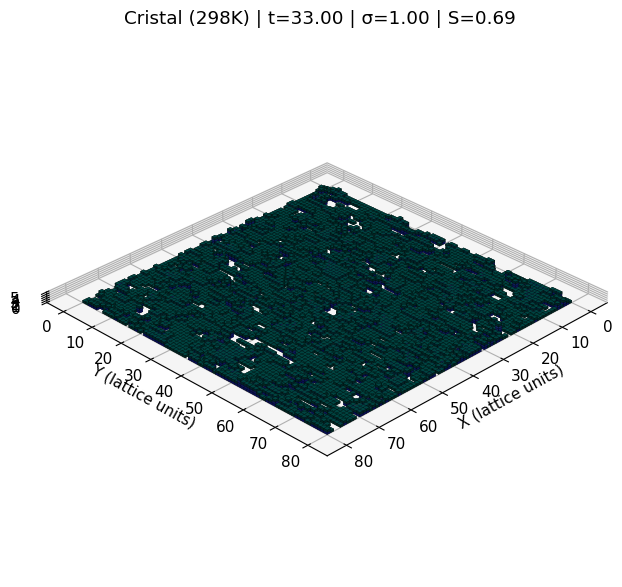

In [29]:
plotter = Plotter_v2(kmc_ani_ab)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_ani_ab,
    t_snapshot=times_ani_ab[-1],
)

In [31]:
plotter.crystal_growth_gif(
    snapshots=snaps_ani_ab,
    save_path="crystal_growth_ani_ab_ts30.gif",
    mode="voxel",        # o "voxel"
    elev=30,
    azim=45,
    cmap="terrain",
    fps=8,
    interval_ms=150,
    dpi=120,
    title_prefix="Crecimiento isotrópico 3D",
    every_n=1,
)

💾 GIF guardado en: crystal_growth_ani_ab_ts30.gif


In [125]:
times = np.arange(0, 14, 1)

L_otros = LatticeSOS_v4(size=(70, 70), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_otros.initialize(mode="seeds", max_height=1, n_seeds=44)

params = KMCParams_v4(
K0_plus= 0.2116718, #0.211,#
K_inc_plus=0.5069325183371898,
E_pb_over_kT_x=1.2704636027368605,
E_pb_over_kT_y=1.2704636027368605,
phi_over_kT= 1.4792478012079329, #3.76, #1.4792478012079329, #
delta_x=2.3,
delta_y=2.3,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc_otros = KMC_BKL_v4(
    lattice=L_otros,
    params=params,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=80,
    constant_concentration=True,  # batch dinámico
)

In [126]:
snaps_otros, stats_otros = kmc_otros.run(t_end=times[-1], snapshot_times=times)

In [2]:
plotter = Plotter_v2(kmc_otros)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_otros,
    t_snapshot=times[12],
)

NameError: name 'Plotter_v2' is not defined

In [22]:
import pandas as pd

conv80_1 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_1_seed_123/conversion_history.csv')
conv80_2 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_2_seed_123/conversion_history.csv')
conv80_3 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_3_seed_123/conversion_history.csv')
conv80_4 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_4_seed_123/conversion_history.csv')
#conv80_5 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_5_seed_123/conversion_history.csv')
#conv80_6 = pd.read_csv('/home/sgaviria/MalariaProject/results/outputs_iso/size_80x80_sigma_6_seed_123/conversion_history.csv')

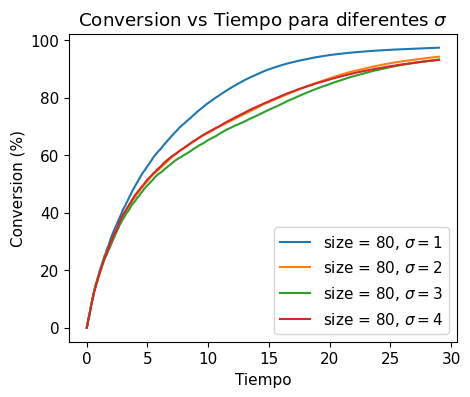

In [23]:
plt.plot(conv80_1['time'], conv80_1['conversion'], label=r'size = 80, $\sigma=1$')
plt.plot(conv80_2['time'], conv80_2['conversion'], label=r'size = 80, $\sigma=2$')
plt.plot(conv80_3['time'], conv80_3['conversion'], label=r'size = 80, $\sigma=3$')
plt.plot(conv80_4['time'], conv80_4['conversion'], label=r'size = 80, $\sigma=4$')
#plt.plot(conv80_5['time'], conv80_5['conversion'], label=r'size = 80, $\sigma=5$')
#plt.plot(conv80_6['time'], conv80_6['conversion'], label=r'size = 80, $\sigma=6$')
plt.legend()
plt.xlabel('Tiempo')
plt.ylabel('Conversion (%)')
plt.title('Conversion vs Tiempo para diferentes $\sigma$')
plt.show()

In [39]:
times = np.arange(0, 5.5, 0.5)
times

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. ])

In [34]:
L_ani_ab_75 = LatticeSOS_v4(size=(75, 75), seed=42)
# L.initialize(mode="random", max_height=1, n_seeds=1905)
L_ani_ab_75.initialize(mode="flat", max_height=1, n_seeds=400)

params_ani_ab_75 = KMCParams_v4(
K0_plus= 11.6718, #0.211,#
K_inc_plus=0.5069325183371898,
E_pb_over_kT_x=0.76085943,
E_pb_over_kT_y=2.19936039,
phi_over_kT= 1.4792478012079329, #3.76, #1.4792478012079329, #
delta_x=0.3,
delta_y=1.7789686274068774,
V=1,
C_eq=15.0,
fixed_sigma=1,   # usa un valor como 3.0 si quieres sigma estático
S_floor=-5.0,
S_ceil=9.0,
)

kmc_ani_ab_75 = KMC_BKL_v4(
    lattice=L_ani_ab_75,
    params=params_ani_ab_75,
    N_bulk0=2000,
    rng_seed=123,
    time_scale=100,
    n_seeds=400,
    constant_concentration=True,  # batch dinámico
)

In [35]:
snaps_ani_ab_75, stats_ani_ab_75 = kmc_ani_ab_75.run(t_end=times[-1], snapshot_times=times)

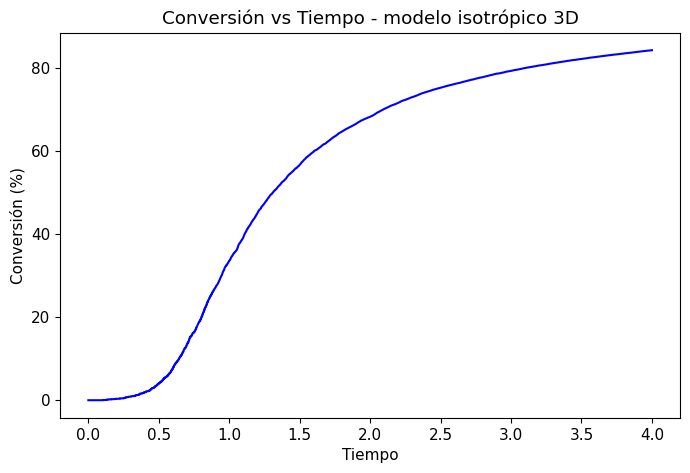

In [36]:
# Armar serie compatible con Plotter (t, heights, conversion)
conversion_series_ani_ab_75 = [(t, None, conv) for t, conv in stats_ani_ab_75["conversion_history"]]

# Graficar conversión vs tiempo
plots = Plotter(kmc_ani_ab_75)
plots.plot_conversion(conversion_series_ani_ab_75, title="Conversión vs Tiempo - modelo isotrópico 3D")

🧩 Snapshot seleccionado: t=4.000


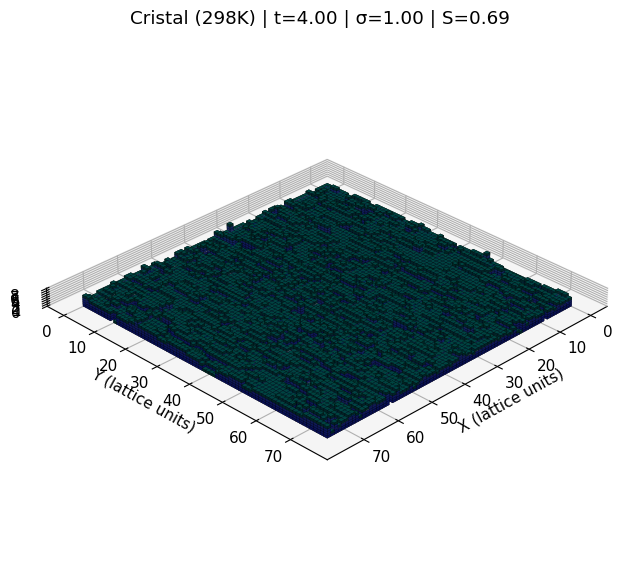

In [37]:
plotter = Plotter_v2(kmc_ani_ab_75)
plotter.plot_crystal_3d(
    mode="voxel",
    snapshots=snaps_ani_ab_75,
    t_snapshot=times[-1],
)

In [49]:
np.arange(1, 8 + 0.5 * 2, 2)

array([1., 3., 5., 7.])

In [10]:
plt.plot(data_txt["Tiempo"], data_txt["Porcentaje"], label="Datos experimentales", marker="o")
plt.plot([t for t, _, _ in conversion_series_ani_ab_75], [conv for _, _, conv in conversion_series_ani_ab_75], label="Simulación kMC")
plt.xlabel("Tiempo (h)")
plt.ylabel("Porcentaje de conversión (%)")
plt.title("Conversión de β-hematina vs Tiempo")
plt.grid(True)

NameError: name 'data_txt' is not defined